In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re

# 日本語フォント設定
plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

In [2]:
def read_xyz_trajectory(filename):
    """XYZ軌跡ファイルを読み込む（エネルギー情報も抽出）"""
    structures = []
    with open(filename, "r") as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        try:
            natoms = int(lines[i].strip())
            comment = lines[i + 1].strip()

            # コメント行からエネルギーを抽出: "E -399.097663315154"
            energy = None
            if " E " in comment:
                energy_str = comment.split(" E ")[-1].strip()
                energy = float(energy_str)

            coords = []
            atoms = []
            for j in range(natoms):
                parts = lines[i + 2 + j].split()
                atoms.append(parts[0])
                coords.append([float(parts[1]), float(parts[2]), float(parts[3])])
            structures.append(
                {
                    "atoms": atoms,
                    "coords": np.array(coords),
                    "comment": comment,
                    "energy": energy,
                }
            )
            i += natoms + 2
        except:
            break
    return structures


def calculate_distance(coord1, coord2):
    """2点間の距離を計算（Angstrom）"""
    return np.linalg.norm(coord1 - coord2)


def parse_irc_energies(logfile):
    """IRCログファイルからエネルギーを抽出"""
    energies_forward = []
    energies_backward = []

    with open(logfile, "r") as f:
        lines = f.readlines()

    in_forward = False
    in_backward = False

    for line in lines:
        if "IRC FORWARD Calculation" in line:
            in_forward = True
            in_backward = False
        elif "IRC BACKWARD Calculation" in line:
            in_forward = False
            in_backward = True

        # エネルギー行を探す: "IRC-ENERGY:" で始まる行
        if "IRC-ENERGY:" in line or "Current Energy" in line:
            match = re.search(r"(-?\d+\.\d+)", line)
            if match:
                energy = float(match.group(1))
                if in_forward:
                    energies_forward.append(energy)
                elif in_backward:
                    energies_backward.append(energy)

    return energies_forward, energies_backward

In [3]:
# Forward軌跡を読み込む
forward_trj = read_xyz_trajectory("irc_IRC_F_trj.xyz")
print(f"Forward structures: {len(forward_trj)}")

# Backward軌跡を読み込む
backward_trj = read_xyz_trajectory("irc_IRC_B_trj.xyz")
print(f"Backward structures: {len(backward_trj)}")

# TS構造（初期構造）
ts_struct = read_xyz_trajectory("tsopt_final.xyz")[0]
print(f"TS structure loaded")

Forward structures: 30
Backward structures: 109
TS structure loaded


In [4]:
# N(1)はインデックス1、C(12)はインデックス12（0-indexed）
n_idx = 1
c_idx = 12

# TS構造の距離
ts_distance = calculate_distance(ts_struct["coords"][n_idx], ts_struct["coords"][c_idx])
print(f"TS N(1)-C(12) distance: {ts_distance:.3f} Å")

# Backward軌跡の距離（逆順にして、TSに近い順に並べる）
backward_distances = []
for struct in reversed(backward_trj):
    dist = calculate_distance(struct["coords"][n_idx], struct["coords"][c_idx])
    backward_distances.append(dist)

# TS
ts_distances = [ts_distance]

# Forward軌跡の距離
forward_distances = []
for struct in forward_trj:
    dist = calculate_distance(struct["coords"][n_idx], struct["coords"][c_idx])
    forward_distances.append(dist)

# 全体の距離リスト
all_distances = backward_distances + ts_distances + forward_distances
print(f"Total points: {len(all_distances)}")

TS N(1)-C(12) distance: 2.178 Å
Total points: 140


In [5]:
# Full軌跡から全てのエネルギーと距離を抽出
full_trj = read_xyz_trajectory("irc_IRC_Full_trj.xyz")
print(f"Full IRC trajectory: {len(full_trj)} structures")

# N(1)はインデックス1、C(12)はインデックス12
n_idx = 1
c_idx = 12

# 全ての距離とエネルギーを抽出
all_distances = []
all_energies = []

for struct in full_trj:
    dist = calculate_distance(struct["coords"][n_idx], struct["coords"][c_idx])
    all_distances.append(dist)
    all_energies.append(struct["energy"])

print(f"Total points: {len(all_distances)}")
print(f"Distance range: {min(all_distances):.3f} - {max(all_distances):.3f} Å")
print(f"Energy range: {min(all_energies):.8f} - {max(all_energies):.8f} Hartree")

Full IRC trajectory: 140 structures
Total points: 140
Distance range: 1.562 - 2.839 Å
Energy range: -399.10655103 - -399.09158977 Hartree


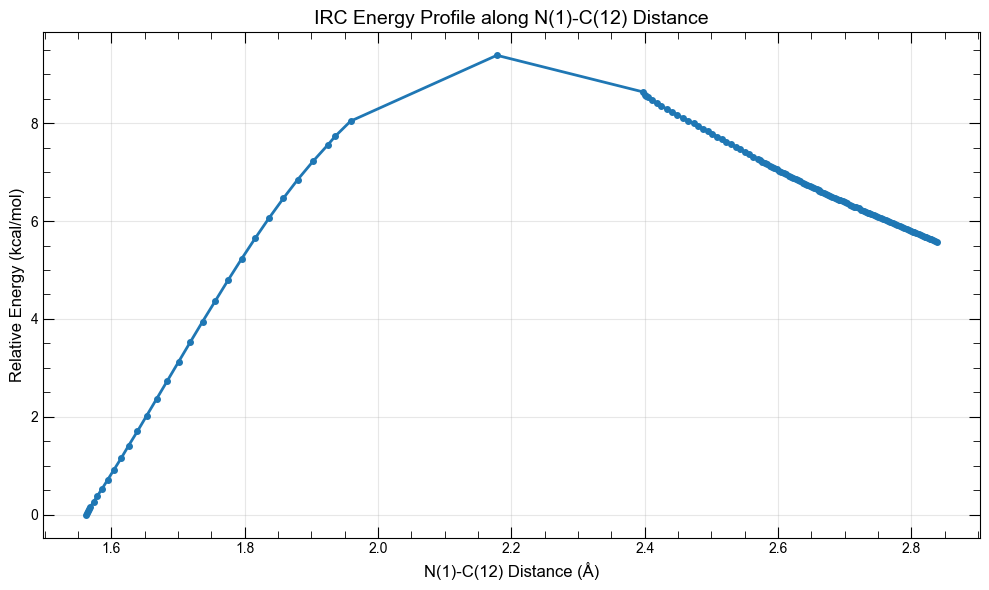

Plot saved as irc_energy_vs_distance.png


In [6]:
# ハートリーをkcal/molに変換
hartree_to_kcal = 627.509474
all_energies_kcal = [(e - min(all_energies)) * hartree_to_kcal for e in all_energies]

# プロット
plt.figure(figsize=(10, 6))
plt.plot(all_distances, all_energies_kcal, "o-", linewidth=2, markersize=4)
plt.xlabel("N(1)-C(12) Distance (Å)", fontsize=12)
plt.ylabel("Relative Energy (kcal/mol)", fontsize=12)
plt.title("IRC Energy Profile along N(1)-C(12) Distance", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("irc_energy_vs_distance.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Plot saved as irc_energy_vs_distance.png")

In [7]:
# データサマリー
print(f"\n=== Energy Summary ===")
print(f"Minimum energy: {min(all_energies_kcal):.2f} kcal/mol")
print(f"Maximum energy: {max(all_energies_kcal):.2f} kcal/mol")
print(f"Energy barrier: {max(all_energies_kcal) - min(all_energies_kcal):.2f} kcal/mol")
print(f"\n=== Distance Summary ===")
print(f"Minimum N(1)-C(12) distance: {min(all_distances):.3f} Å")
print(f"Maximum N(1)-C(12) distance: {max(all_distances):.3f} Å")
print(f"TS N(1)-C(12) distance: {ts_distance:.3f} Å")


=== Energy Summary ===
Minimum energy: 0.00 kcal/mol
Maximum energy: 9.39 kcal/mol
Energy barrier: 9.39 kcal/mol

=== Distance Summary ===
Minimum N(1)-C(12) distance: 1.562 Å
Maximum N(1)-C(12) distance: 2.839 Å
TS N(1)-C(12) distance: 2.178 Å
